In [70]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.impute import KNNImputer

# 1. Работа с данными

Загрузка данных

In [71]:
train_df = pd.read_csv("data\\prices_train.csv", index_col=0)
X = train_df.iloc[:, :-1]
y = train_df.iloc[:, -1]

Выведем процент пропущенных значений

In [72]:
nan_df = (X.isnull().mean() * 100).reset_index()
nan_df.columns = ["column_name", "percentage"]
nan_df.sort_values("percentage", ascending=False, inplace=True)
nan_df

,column_name,percentage
3,X4 number of convenience stores,4.229607
1,X2 house age,2.416918
2,X3 distance to the nearest MRT station,2.114804
0,X1 transaction date,0.000000
4,X5 latitude,0.000000
5,X6 longitude,0.000000


Видно, что процент пропущенных значений довольно маленький, значит уже можно предположить, что заполнение пропусков средним или медианой будет работать нормально. Также стоит заметить, что пропуски имеют только признаки X2, X3, X4.

Посмотрим на распределение данных. Для этого выведем гитограммы распределения каждого признака:

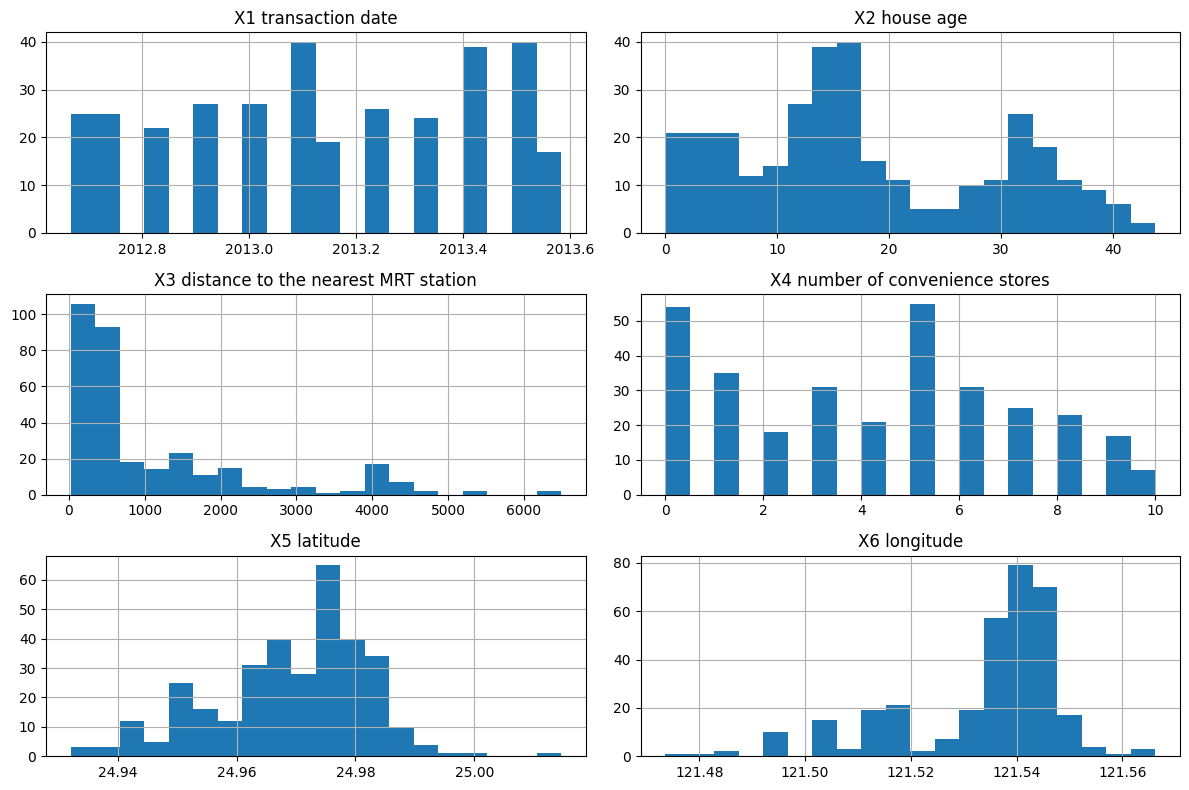

In [73]:
X.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

Видим, что почти у всех признаков отсутствует нормальное распределение, это стоит учесть при заполнении пропусков и обучении модели

Рассмотри корреляции между признаками:

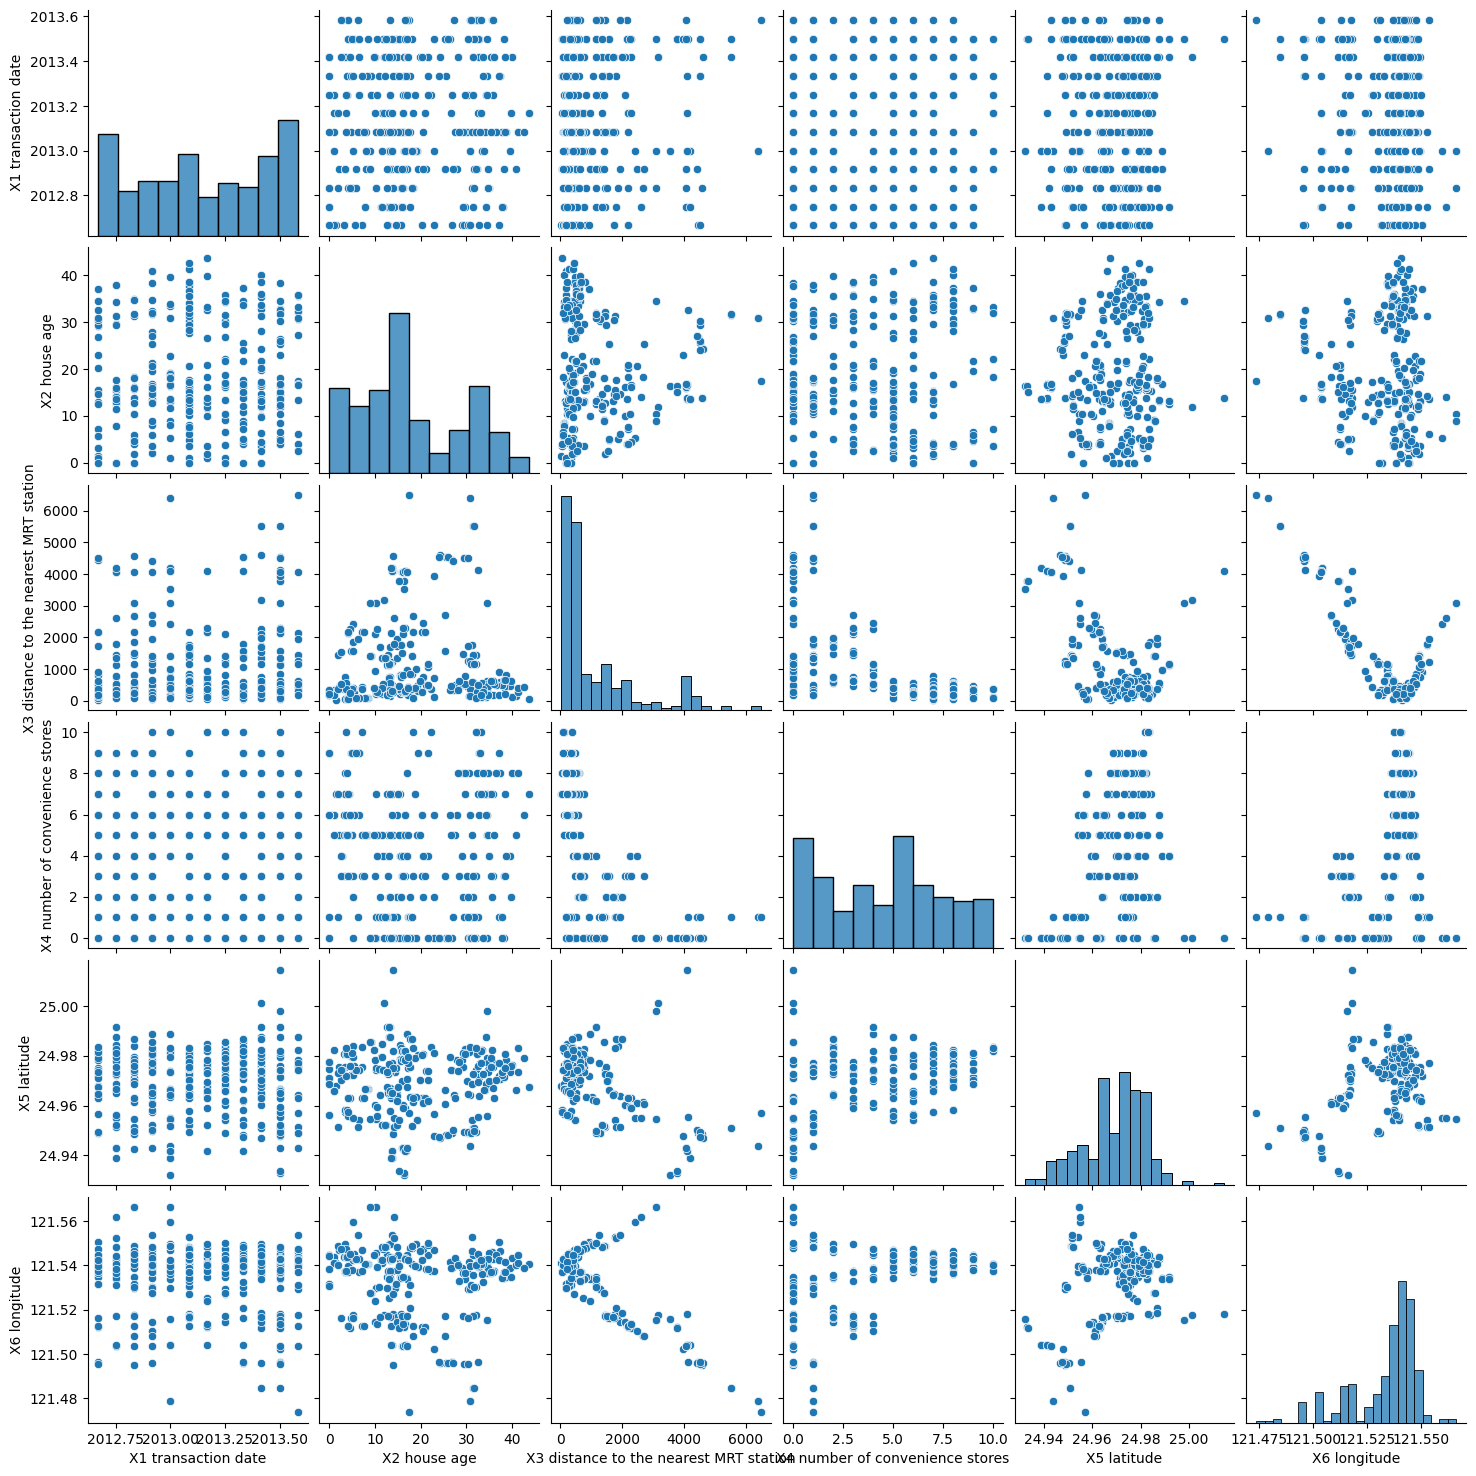

In [74]:
sns.pairplot(X)
plt.show()

Построим тепловую карту, чтобы выявить корреляции между признаками

<Axes: >

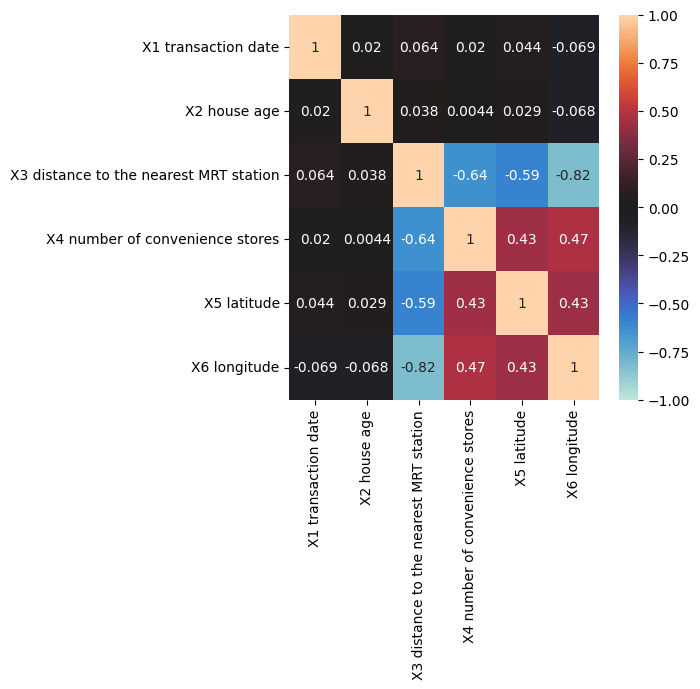

In [75]:
fig, ax = plt.subplots(figsize=(5,5)) 
sns.heatmap(
    X.corr("pearson"),
    vmin=-1.0,
    vmax=1.0,
    cmap="icefire",
    annot=True,
    ax=ax,
)

Из тепловой карты видно, что признак X3 и X6 заметно коррелируют. Однако признаков всего 6, значит модель не перегружена и коррелирующий признак можно не удалять.

Рассмотрим корреляции между признаками и целевым значением, возможно некоторые признаки с пропусками имеют слишком низкую корреляцию, и их можно исключить.

In [76]:
train_df.corr()["Y house price of unit area"]

X1 transaction date                       0.103270
X2 house age                             -0.256460
X3 distance to the nearest MRT station   -0.672736
X4 number of convenience stores           0.575161
X5 latitude                               0.541982
X6 longitude                              0.538171
Y house price of unit area                1.000000
Name: Y house price of unit area, dtype: float64

Видим, что признак X1 имеет низкую корреляцию, однако признаков всего 6, так что риск переобучения модели незначительный, значит можно не исключать признаки.

Рассмотрим наличие выбросов:

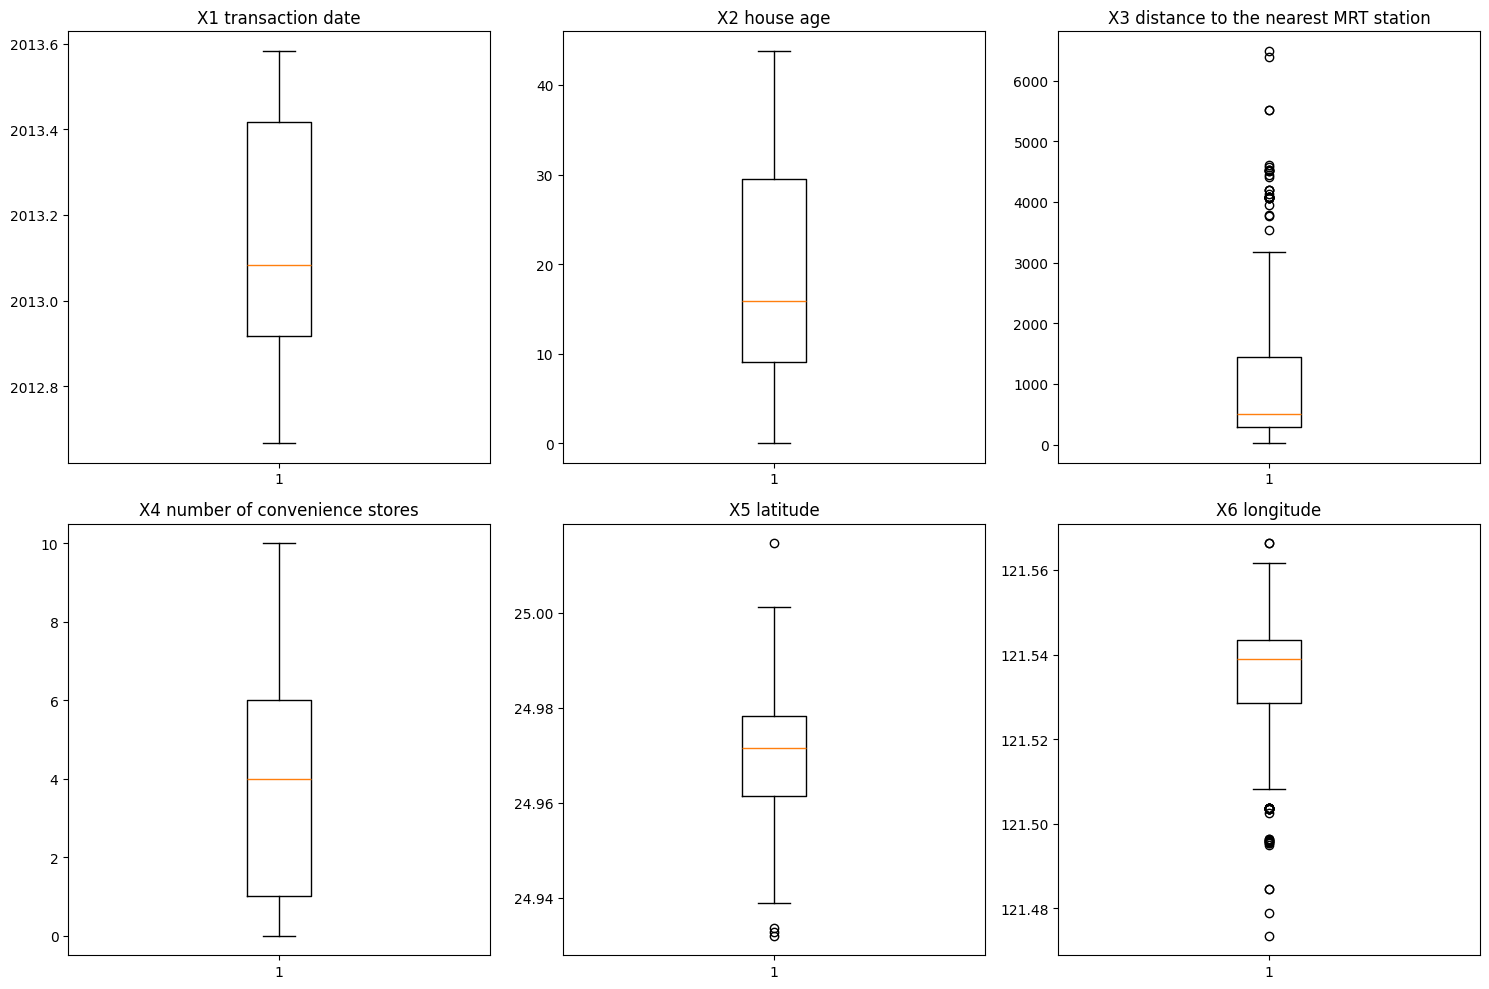

In [77]:
import math

df_ = X.dropna()

n = len(df_.columns)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

axes = axes.flatten()

for i, col in enumerate(df_.columns):
    axes[i].boxplot(df_[col])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Видим, что признаки X3 и X6 имеют некоторое количество выбросов, нужно будет попробовать различные способы обработки выбросов.

# 2. Выбор метода заполнения пропусков

Для выбора метода заполнения пропусков будем заполнять пропуски разными методами и оценивать качество модели при помощи кросс-валидации
При этом выбросы пока что никак не обрабатываем

In [78]:
def count_mse(pipeline, X, y):
    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="neg_mean_squared_error"
    )

    mse_scores = -scores
    mean_score = np.mean(mse_scores)

    return mean_score

#### Заполнение пропусков средним значением

In [79]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", LinearRegression())
])

count_mse(pipeline, X, y)

np.float64(80.10227656551645)

#### Заполнение пропусков медианой

In [80]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LinearRegression())
])

count_mse(pipeline, X, y)

np.float64(79.97740127909107)

#### Заполнение пропусков алгоритмом kNN (k ближайших соседей)

In [81]:
pipeline = Pipeline([
    ("imputer", KNNImputer(n_neighbors=2)),
    ("model", LinearRegression())
])

count_mse(pipeline, X, y)

np.float64(81.16931063891698)

#### Заполнение пропусков алгоритмом MICE (обучение модели предсказывать пропущенные значения на основе других признаков), так как ранее было выявлено, что некоторые признаки коррелируют

In [82]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

pipeline = Pipeline([
    ("imputer", IterativeImputer()),
    ("model", LinearRegression())
])

count_mse(pipeline, X, y)

np.float64(80.18219347182173)

Лучший результат показал вариант заполнения пропусков медианой, однако результаты других методов отличаются незначительно.

# 3. Обработка выбросов и скейлинг

#### Удаление выбросов

In [83]:
for col, upper_bound in (
    ('X3 distance to the nearest MRT station', 3250),
    ('X5 latitude', 25.00),
    ('X6 longitude', 121.57),
):
    df_ =train_df.drop(train_df[train_df[col] > upper_bound].index)
    
for col, lower_bound in (
    ('X5 latitude', 24.94),
    ('X6 longitude', 121.51),
):
    df_ = train_df.drop(train_df[train_df[col] < lower_bound].index)
    
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LinearRegression())
])

count_mse(pipeline, df_.iloc[:, :-1], df_.iloc[:, -1])

np.float64(82.40154513596696)

Удаление выбросов только ухудшило результат, возможно были потеряны важные данные

### Попробуем методы скейлинга

#### Нормализация

In [84]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

count_mse(pipeline, X, y)

np.float64(79.97740127909115)

#### Логарифмирование признаков

In [85]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log1p)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("model", LinearRegression())
])

count_mse(pipeline, X, y)

np.float64(63.56233673973104)

Видим, что логарифмирование признаков сильно снизило ошибку

#### RobustScaler

In [86]:
from sklearn.preprocessing import RobustScaler

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("model", LinearRegression())
])

count_mse(pipeline, X, y)

np.float64(79.97740127909115)

В итоге лучший результат дал скейлинг логарифмированием 

# 4. Регуляризация

#### L1 регуляризация

In [87]:
from sklearn.linear_model import Lasso

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("model", Lasso(alpha=1.0))
])

count_mse(pipeline, X, y)

np.float64(82.05902245905216)

In [88]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("model", Lasso(alpha=0.1))
])

count_mse(pipeline, X, y)

np.float64(79.02178293522634)

In [89]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("model", Lasso(alpha=0.01))
])

count_mse(pipeline, X, y)

np.float64(78.9714704624636)

Из результатов видно, что L1 регуляризация не дала прирост к точности

#### L2 регуляризация

In [90]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("model", Ridge(alpha=1.0))
])

count_mse(pipeline, X, y)

np.float64(78.954833457515)

In [91]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("model", Ridge(alpha=0.1))
])

count_mse(pipeline, X, y)

np.float64(78.95623473491277)

In [92]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("model", Ridge(alpha=0.01))
])

count_mse(pipeline, X, y)

np.float64(78.8594125393341)

Из результатов видно, что L2 регуляризация также не дала прирост к точности

Однако важно заметить, что регуляризация чувствительна к распределению, поэтому добавим наормализацию:

#### L1 регуляризация

In [93]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=1.0))
])

count_mse(pipeline, X, y)

np.float64(66.83740560871408)

In [94]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1))
])

count_mse(pipeline, X, y)

np.float64(63.564732347377955)

In [95]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.01))
])

count_mse(pipeline, X, y)

np.float64(63.54857823524203)

#### L2 регуляризация

In [96]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

count_mse(pipeline, X, y)

np.float64(63.54322454022648)

In [97]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=0.1))
])

count_mse(pipeline, X, y)

np.float64(63.56017756997833)

In [98]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log", log_transformer),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=0.01))
])

count_mse(pipeline, X, y)

np.float64(63.56211827771017)

Теперь заметно, что L2 регуляризация со скейлингом дает наилучший результат

# 5. Feature engineering

Попробуем добавить новые признаки различными методами основываясь на информации о выбросах и корреляциях признаков

In [99]:

from sklearn.base import BaseEstimator, TransformerMixin


class FeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.age_thresholds_ = None
        self.dist_thresholds_ = None
        self.store_thresholds_ = None
        self.lat_thresholds_ = None
        self.lon_thresholds_ = None
        self.quantiles_ = [0.3, 0.5, 0.8]
        
    def fit(self, X, y=None):
        age = X['X2 house age']
        dist = X['X3 distance to the nearest MRT station']
        stores = X['X4 number of convenience stores']
        lat = X['X5 latitude']
        lon = X['X6 longitude']
        
        self.age_thresholds_ = [age.quantile(q) for q in self.quantiles_]
        self.dist_thresholds_ = [dist.quantile(q) for q in self.quantiles_]
        self.store_thresholds_ = [stores.quantile(q) for q in self.quantiles_]
        self.lat_thresholds_ = [lat.quantile(q) for q in self.quantiles_]
        self.lon_thresholds_ = [lon.quantile(q) for q in self.quantiles_]
        
        return self
    
    def transform(self, X):
        out = X.copy()
        
        age = X['X2 house age']
        dist = X['X3 distance to the nearest MRT station']
        stores = X['X4 number of convenience stores']
        lat = X['X5 latitude']
        lon = X['X6 longitude']
        
        out['stores_cubed'] = stores ** 3
        out['dist_cubed'] = dist ** 3
        out['stores_sqrt'] = stores.clip(lower=0) ** 0.5
        out['stores_lon'] = stores * lon
        out['lat_lon'] = lat * lon
        out['dist_lon'] = dist * lon
        out['dist_lat'] = dist * lat
        out['dist_stores'] = dist * stores
        

        out['age_q30'] = (age > self.age_thresholds_[0]).astype(float)
        out['age_q50'] = (age > self.age_thresholds_[1]).astype(float)
        out['age_q80'] = (age > self.age_thresholds_[2]).astype(float)
        
        out['dist_q30'] = (dist > self.dist_thresholds_[0]).astype(float)
        out['dist_q50'] = (dist > self.dist_thresholds_[1]).astype(float)
        out['dist_q80'] = (dist > self.dist_thresholds_[2]).astype(float)
        
        out['stores_q30'] = (stores > self.store_thresholds_[0]).astype(float)
        out['stores_q50'] = (stores > self.store_thresholds_[1]).astype(float)
        out['stores_q80'] = (stores > self.store_thresholds_[2]).astype(float)
        
        out['lat_q30'] = (lat > self.lat_thresholds_[0]).astype(float)
        out['lat_q50'] = (lat > self.lat_thresholds_[1]).astype(float)
        out['lat_q80'] = (lat > self.lat_thresholds_[2]).astype(float)
        
        out['lon_q30'] = (lon > self.lon_thresholds_[0]).astype(float)
        out['lon_q50'] = (lon > self.lon_thresholds_[1]).astype(float)
        out['lon_q80'] = (lon > self.lon_thresholds_[2]).astype(float)
        
        return out


In [100]:
from sklearn.preprocessing import FunctionTransformer

columns = [
    'X1 transaction date',
    'X2 house age',
    'X3 distance to the nearest MRT station',
    'X4 number of convenience stores',
    'X5 latitude',
    'X6 longitude',
]

to_df = FunctionTransformer(
    lambda x: pd.DataFrame(x, columns=columns),
    validate=False
)

In [101]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("to_df", to_df),
    ('feature', FeatureEngineering()),
    ("log", log_transformer),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=0.01))
])

count_mse(pipeline, X, y)

np.float64(63.344531825514686)

# 5. Обучение модели

In [102]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("to_df", to_df),
    ('feature', FeatureEngineering()),
    ("log", log_transformer),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=0.01))
])

model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('to_df', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If

In [103]:
test_df = pd.read_csv("data\\prices_test.csv", index_col=0)

y_pred = model.predict(test_df)

pred_df = pd.DataFrame(y_pred, columns=["Y house price of unit area"])

pred_df.to_csv("out.csv", index_label="index")